In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import os
import re
base_path = 'output/'

dfs_all = []

# loop over encoders
for encoder in os.listdir(base_path):
    encoder_path = os.path.join(base_path, encoder)

    if not os.path.isdir(encoder_path) or encoder == '.ipynb_checkpoints':
        continue

    print('%%%%%%%%%%%%%%%%%%%%%%')
    print(encoder)

    dfs = []

    # loop over seeds
    for seed_dir in os.listdir(encoder_path):
        seed_path = os.path.join(encoder_path, seed_dir)

        if not os.path.isdir(seed_path):
            continue

        # extract seed number (seed1 → 1)
        seed = int(re.search(r'\d+', seed_dir).group())

        # loop over result files
        for file in glob.glob(os.path.join(seed_path, 'results_hafl_life_*.csv')):

            # extract half-life from filename
            hl = int(re.search(r'hafl_life_(\d+)', file).group(1))

            df = pd.read_csv(file)

            df['encoder'] = encoder
            df['seed'] = seed
            df['half_life'] = hl

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # keep your original swap if still needed
    df['temp'] = df['model']
    df['model'] = df['time_window']
    df['time_window'] = df['temp']
    df.drop(columns='temp', inplace=True)

    # same aggregation as before
    plot_df = (
        df.groupby(
            ["encoder", "seed", "model", "time_window", "half_life"],
            as_index=False
        )[["recall@10", "ndcg@10"]]
        .mean()
    )

    dfs_all.append(plot_df)

# final dataframe
df = pd.concat(dfs_all, ignore_index=True)

%%%%%%%%%%%%%%%%%%%%%%
embeddinggemma-300m
%%%%%%%%%%%%%%%%%%%%%%
all-MiniLM-L6-v2
%%%%%%%%%%%%%%%%%%%%%%
gte-multilingual-base
%%%%%%%%%%%%%%%%%%%%%%
msmarco-bert-base-dot-v5
%%%%%%%%%%%%%%%%%%%%%%
msmarco-bert-base-dot-v5_twotower
%%%%%%%%%%%%%%%%%%%%%%
all-MiniLM-L6-v2_twotower


In [2]:
df = df[~df['encoder'].str.contains('twotower', na=False)].copy()

In [3]:
encoder_names = {
    'embeddinggemma-300m': 'Gemma-300M',
    'all-MiniLM-L6-v2': 'MiniLM-L6',
    'gte-multilingual-base': 'GTE-Multi',
    'msmarco-bert-base-dot-v5': 'BERT-MSMARCO',
    #'msmarco-bert-base-dot-v5_twotower': 'BERT-MSMARCO_2tower',
    #'all-MiniLM-L6-v2_twotower': 'MiniLM-L6_2tower',
}


df['enc'] = df['encoder'].map(encoder_names)

model_names = {
    'deepseek-r1':'deepseek',
    'gemini-2.0-flash': 'gemini',
    'llama3.2:3b-instruct-q8_0':'llama'
    }

df['model'] = df['model'].map(model_names)

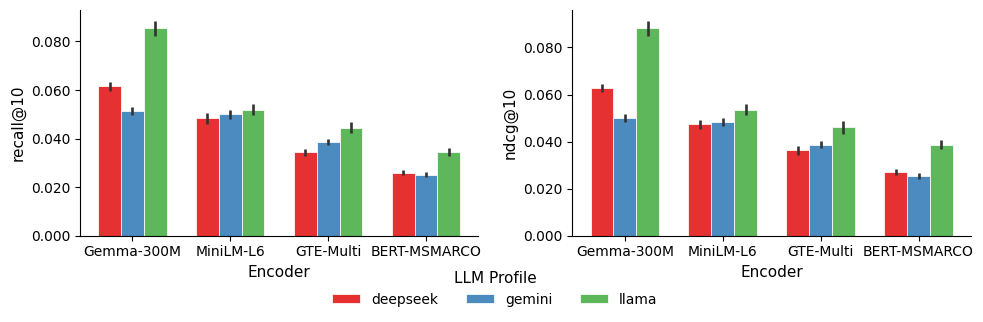

In [4]:
import matplotlib.ticker as mticker

metrics   = ['recall@10', 'ndcg@10']
enc_order = ['Gemma-300M','MiniLM-L6','GTE-Multi', 'BERT-MSMARCO']
llm_order = ['deepseek', 'gemini', 'llama']
palette   = sns.color_palette("Set1", len(llm_order))

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 3),
    sharey=False
)

for ax, metric in zip(axes, metrics):
    # Compute mean + 95% CI per (encoder, llm)
    agg = (
        df.groupby(['enc', 'model'])[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    agg['ci95'] = 1.96 * agg['std'] / np.sqrt(agg['count'])

    n_enc = len(enc_order)
    n_llm = len(llm_order)
    bar_width = 0.7 / n_llm
    x = np.arange(n_enc)

    for i, (llm, color) in enumerate(zip(llm_order, palette)):
        subset = agg[agg['model'] == llm].set_index('enc')
        means  = [subset.loc[e, 'mean'] if e in subset.index else np.nan for e in enc_order]
        cis    = [subset.loc[e, 'ci95'] if e in subset.index else np.nan for e in enc_order]

        offset = (i - n_llm / 2 + 0.5) * bar_width
        bars = ax.bar(
            x + offset, means,
            width=bar_width,
            label=llm,
            color=color,
            edgecolor='white',
            linewidth=0.6,
            alpha=0.9
        )
        ax.errorbar(
            x + offset, means,
            yerr=cis,
            fmt='none',
            color='#333333',
            capsize=0,
            linewidth=1.9
        )

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(enc_order, fontsize=10)
    #ax.set_title(metric.upper(), fontsize=13, pad=10)
    ax.set_xlabel('Encoder', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.spines[['top', 'right']].set_visible(False)

# Shared legend below both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='LLM Profile',
    loc='lower center',
    ncol=len(llm_order),
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

#fig.suptitle('Encoder × LLM Profile: Recall@10 and NDCG@10', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('figures/encoder_llm_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()

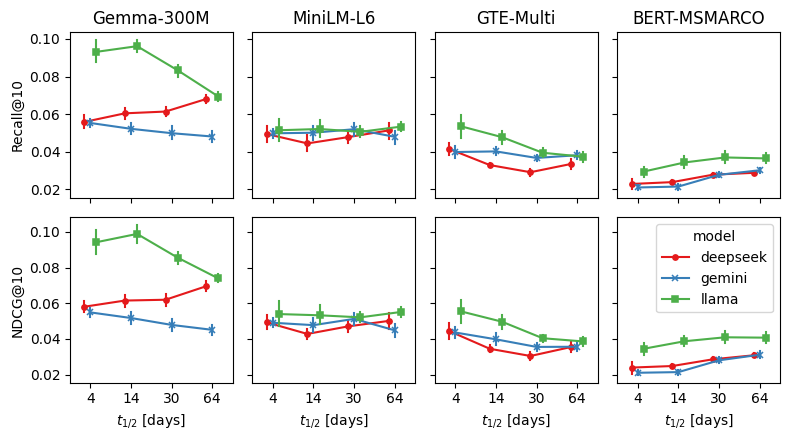

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

encoders = df['enc'].unique()

fig, axes = plt.subplots(
    2, len(encoders),
    figsize=(8, 4.5),
    sharey='row',
    sharex=True
)

for i, enc in enumerate(encoders):
    
    temp = df[df['enc'] == enc]
    
    # Recall@10
    sns.pointplot(
        data=temp,
        x='half_life',
        y='recall@10',
        hue='model',
        ax=axes[0, i],
        palette='Set1',
        dodge=0.3,
        markers=["o","x","s"],
        linewidth = 1.5
    )
    
    # NDCG@10
    sns.pointplot(
        data=temp,
        x='half_life',
        y='ndcg@10',
        hue='model',
        ax=axes[1, i],
        palette='Set1',
        dodge=0.3,
        markers=["o","x","s"],
        linewidth = 1.5)
    
    axes[0, i].set_title(enc)
    axes[1, i].set_xlabel(r"$t_{1/2}$ [days]")
    if i != 3:
        axes[0, i].get_legend().remove()
        axes[1, i].get_legend().remove()

for ax in axes[0, :]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

axes[0, 0].set_ylabel("Recall@10")
axes[1, 0].set_ylabel("NDCG@10")


    


plt.tight_layout()
plt.savefig("recall_vs_halflife.pdf", bbox_inches='tight')

plt.show()


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Gemma-300M


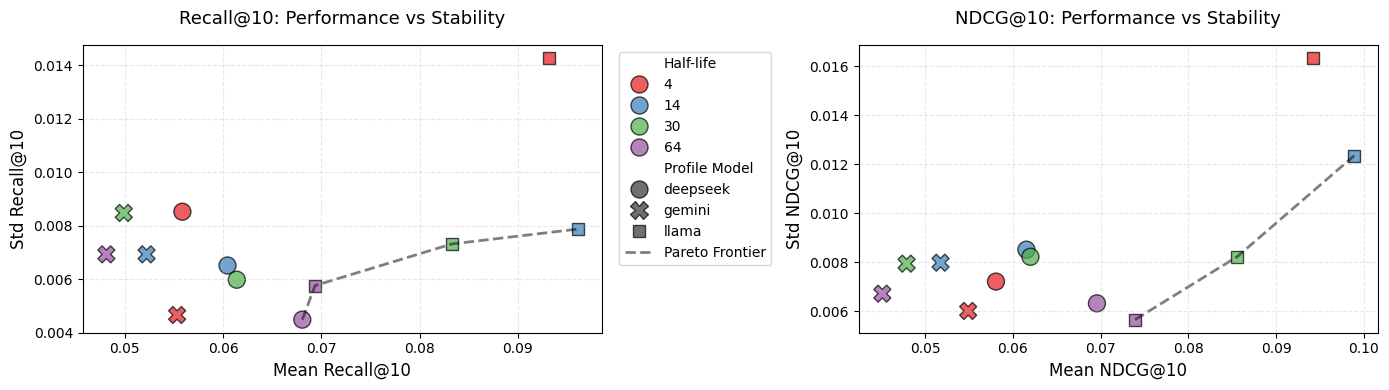

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
MiniLM-L6


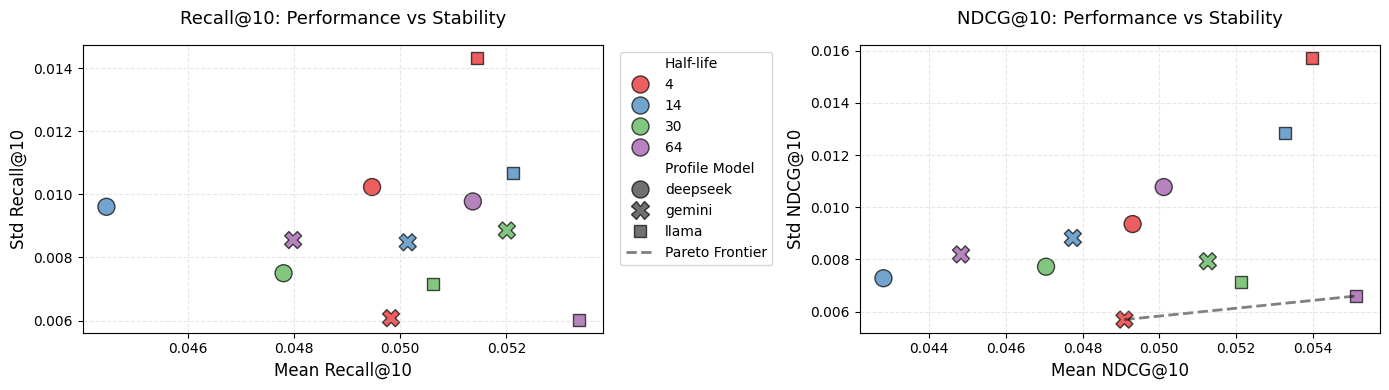

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
GTE-Multi


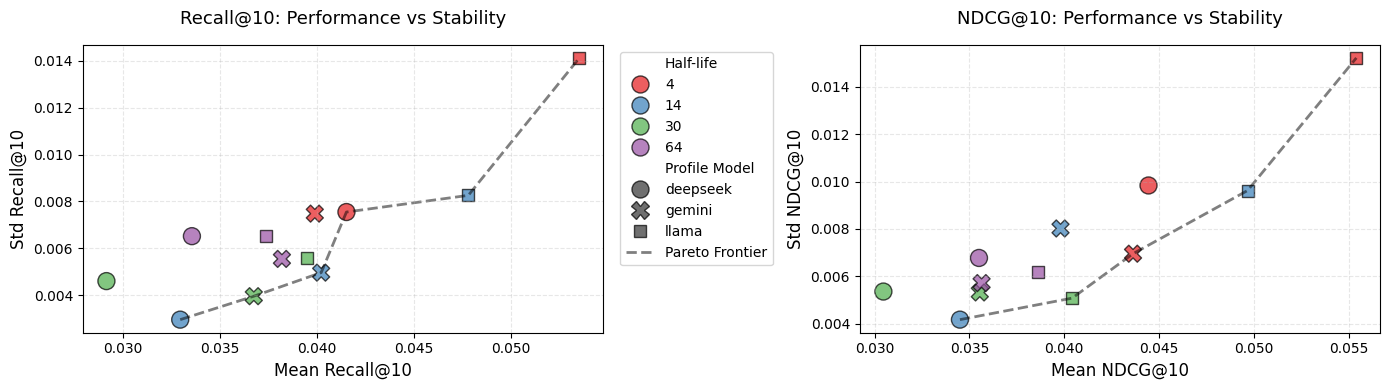

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
BERT-MSMARCO


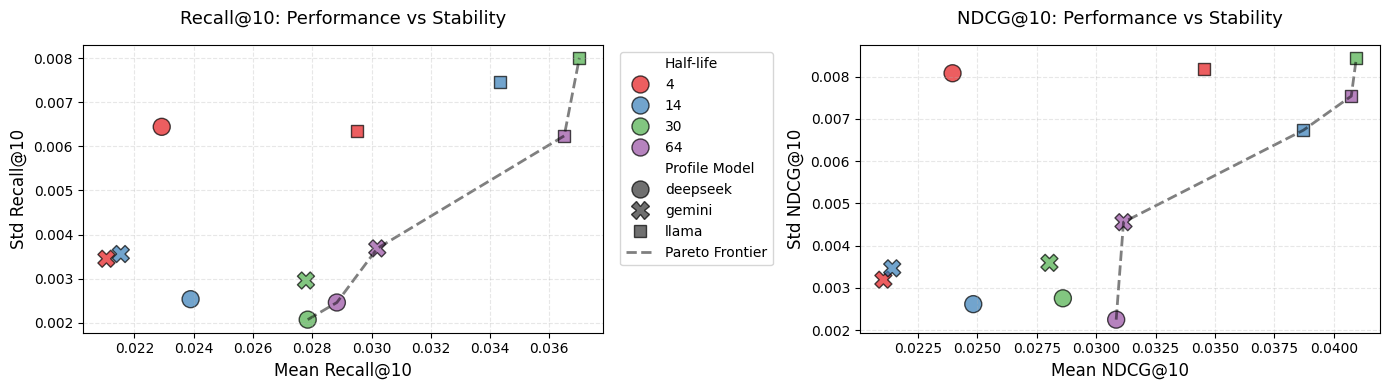

In [75]:
for enc in df.enc.unique():
    print(100*'%')
    print(enc)
    temp_recall = df[df.enc == enc].groupby(['half_life','model'])['recall@10'].agg(['mean','std']).reset_index()
    temp_ndcg = df[df.enc == enc].groupby(['half_life','model'])['ndcg@10'].agg(['mean','std']).reset_index()
    
    # Rename for better legend labels
    temp_recall = temp_recall.rename(columns={'half_life': 'Half-life', 'model': 'Profile Model'})
    temp_ndcg = temp_ndcg.rename(columns={'half_life': 'Half-life', 'model': 'Profile Model'})
    
    def get_pareto_frontier(df, x_col='mean', y_col='std'):
        """Get Pareto frontier: maximize x (mean), minimize y (std)"""
        df_sorted = df.sort_values(x_col, ascending=False).copy()
        pareto = []
        min_std = float('inf')
        
        for idx, row in df_sorted.iterrows():
            if row[y_col] < min_std:
                pareto.append(idx)
                min_std = row[y_col]
        
        return df.loc[pareto].sort_values(x_col)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Recall@10 (left)
    sns.scatterplot(
        data=temp_recall, 
        x='mean', 
        y='std', 
        hue='Half-life', 
        style='Profile Model',
        palette='Set1',
        s=150,
        alpha=0.7,
        edgecolor='black',
        linewidth=1,
        ax=axes[0]
    )
    
    # Add Pareto frontier for Recall
    pareto_recall = get_pareto_frontier(temp_recall)
    axes[0].plot(
        pareto_recall['mean'], 
        pareto_recall['std'], 
        'k--', 
        linewidth=2, 
        alpha=0.5, 
        label='Pareto Frontier',
        zorder=1
    )
    
    
    
    axes[0].set_xlabel('Mean Recall@10', fontsize=12)
    axes[0].set_ylabel('Std Recall@10', fontsize=12)
    axes[0].set_title('Recall@10: Performance vs Stability', fontsize=13, pad=15)
    axes[0].grid(alpha=0.3, linestyle='--')
    
    # NDCG@10 (right)
    sns.scatterplot(
        data=temp_ndcg, 
        x='mean', 
        y='std', 
        hue='Half-life', 
        style='Profile Model',
        palette='Set1',
        s=150,
        alpha=0.7,
        edgecolor='black',
        linewidth=1,
        ax=axes[1],
        legend=False
    )
    
    # Add Pareto frontier for NDCG
    pareto_ndcg = get_pareto_frontier(temp_ndcg)
    axes[1].plot(
        pareto_ndcg['mean'], 
        pareto_ndcg['std'], 
        'k--', 
        linewidth=2, 
        alpha=0.5, 
        label='Pareto Frontier',
        zorder=1
    )
    
    
    
    axes[1].set_xlabel('Mean NDCG@10', fontsize=12)
    axes[1].set_ylabel('Std NDCG@10', fontsize=12)
    axes[1].set_title('NDCG@10: Performance vs Stability', fontsize=13, pad=15)
    axes[1].grid(alpha=0.3, linestyle='--')
    
    # Keep legend only on left plot
    axes[0].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    
    plt.tight_layout()
    plt.show()

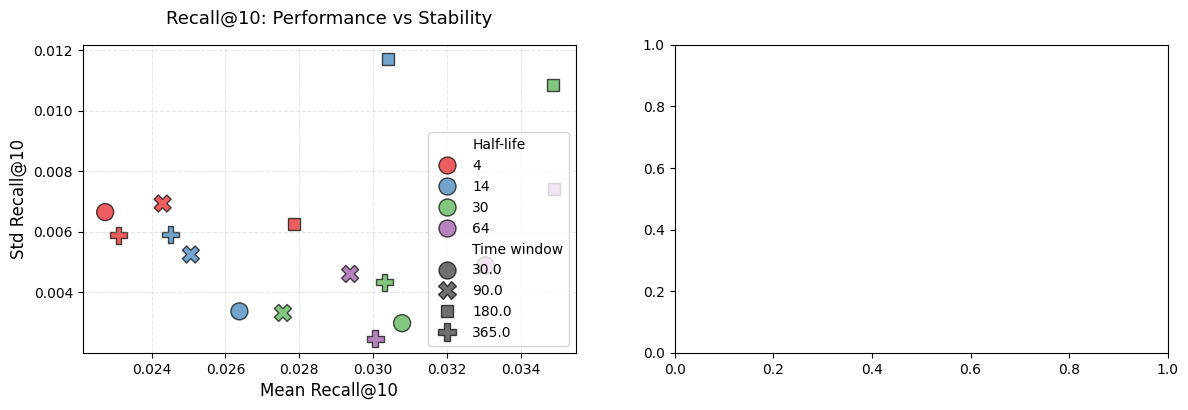

In [97]:

temp_recall = df[df.enc == enc].groupby(['half_life','time_window'])['recall@10'].agg(['mean','std']).reset_index()
temp_ndcg = df[df.enc == enc].groupby(['half_life','time_window'])['ndcg@10'].agg(['mean','std']).reset_index()
    
# Rename for better legend labels
temp_recall = temp_recall.rename(columns={'half_life': 'Half-life', 'time_window': 'Time window'})
temp_ndcg = temp_ndcg.rename(columns={'half_life': 'Half-life', 'time_window': 'Time window'})


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
# Recall@10 (left)
sns.scatterplot(
        data=temp_recall, 
        x='mean', 
        y='std', 
        hue='Half-life', 
        style='Time window',
        palette='Set1',
        s=150,
        alpha=0.7,
        edgecolor='black',
        linewidth=1,
        ax=axes[0]
    )
    
    
    
    
axes[0].set_xlabel('Mean Recall@10', fontsize=12)
axes[0].set_ylabel('Std Recall@10', fontsize=12)
axes[0].set_title('Recall@10: Performance vs Stability', fontsize=13, pad=15)
axes[0].grid(alpha=0.3, linestyle='--')

In [80]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
# Perform ANOVA
df['recall'] = df['recall@10']
model = ols('recall ~ C(half_life)*C(time_window)*C(model)', data=df[df.enc == 'Gemma-300M']).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                        sum_sq     df            F  \
C(half_life)                          0.002152    3.0    47.118261   
C(time_window)                        0.001734    3.0    37.976998   
C(model)                              0.049075    2.0  1611.995012   
C(half_life):C(time_window)           0.002815    9.0    20.548744   
C(half_life):C(model)                 0.008678    6.0    95.014263   
C(time_window):C(model)               0.004659    6.0    51.011416   
C(half_life):C(time_window):C(model)  0.001431   18.0     5.222265   
Residual                              0.002923  192.0          NaN   

                                             PR(>F)  
C(half_life)                           7.242164e-23  
C(time_window)                         2.579762e-19  
C(model)                              9.535094e-121  
C(half_life):C(time_window)            5.204953e-24  
C(half_life):C(model)                  8.962200e-55  
C(time_window):C(model)                3.2870

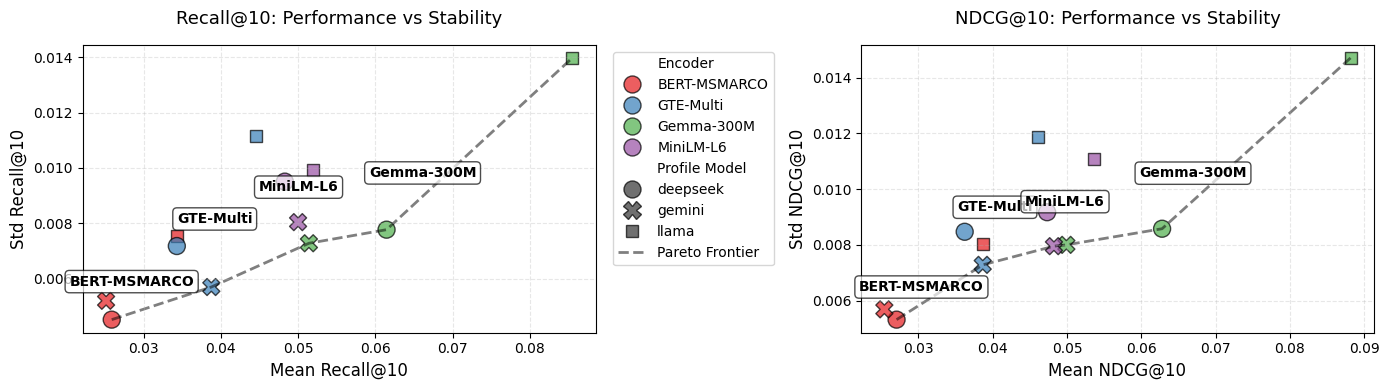

In [36]:
temp_recall = df.groupby(['enc','model'])['recall@10'].agg(['mean','std']).reset_index()
temp_ndcg = df.groupby(['enc','model'])['ndcg@10'].agg(['mean','std']).reset_index()

# Rename for better legend labels
temp_recall = temp_recall.rename(columns={'enc': 'Encoder', 'model': 'Profile Model'})
temp_ndcg = temp_ndcg.rename(columns={'enc': 'Encoder', 'model': 'Profile Model'})

def get_pareto_frontier(df, x_col='mean', y_col='std'):
    """Get Pareto frontier: maximize x (mean), minimize y (std)"""
    df_sorted = df.sort_values(x_col, ascending=False).copy()
    pareto = []
    min_std = float('inf')
    
    for idx, row in df_sorted.iterrows():
        if row[y_col] < min_std:
            pareto.append(idx)
            min_std = row[y_col]
    
    return df.loc[pareto].sort_values(x_col)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Recall@10 (left)
sns.scatterplot(
    data=temp_recall, 
    x='mean', 
    y='std', 
    hue='Encoder', 
    style='Profile Model',
    palette='Set1',
    s=150,
    alpha=0.7,
    edgecolor='black',
    linewidth=1,
    ax=axes[0]
)

# Add Pareto frontier for Recall
pareto_recall = get_pareto_frontier(temp_recall)
axes[0].plot(
    pareto_recall['mean'], 
    pareto_recall['std'], 
    'k--', 
    linewidth=2, 
    alpha=0.5, 
    label='Pareto Frontier',
    zorder=1
)

# Add encoder labels for Recall
for enc in temp_recall['Encoder'].unique():
    enc_data = temp_recall[temp_recall['Encoder'] == enc]
    mean_x = enc_data['mean'].mean()
    mean_y = enc_data['std'].mean()
    axes[0].annotate(
        enc, 
        xy=(mean_x, mean_y),
        fontsize=10,
        weight='bold',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

axes[0].set_xlabel('Mean Recall@10', fontsize=12)
axes[0].set_ylabel('Std Recall@10', fontsize=12)
axes[0].set_title('Recall@10: Performance vs Stability', fontsize=13, pad=15)
axes[0].grid(alpha=0.3, linestyle='--')

# NDCG@10 (right)
sns.scatterplot(
    data=temp_ndcg, 
    x='mean', 
    y='std', 
    hue='Encoder', 
    style='Profile Model',
    palette='Set1',
    s=150,
    alpha=0.7,
    edgecolor='black',
    linewidth=1,
    ax=axes[1],
    legend=False
)

# Add Pareto frontier for NDCG
pareto_ndcg = get_pareto_frontier(temp_ndcg)
axes[1].plot(
    pareto_ndcg['mean'], 
    pareto_ndcg['std'], 
    'k--', 
    linewidth=2, 
    alpha=0.5, 
    label='Pareto Frontier',
    zorder=1
)

# Add encoder labels for NDCG
for enc in temp_ndcg['Encoder'].unique():
    enc_data = temp_ndcg[temp_ndcg['Encoder'] == enc]
    mean_x = enc_data['mean'].mean()
    mean_y = enc_data['std'].mean()
    axes[1].annotate(
        enc, 
        xy=(mean_x, mean_y),
        fontsize=10,
        weight='bold',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )

axes[1].set_xlabel('Mean NDCG@10', fontsize=12)
axes[1].set_ylabel('Std NDCG@10', fontsize=12)
axes[1].set_title('NDCG@10: Performance vs Stability', fontsize=13, pad=15)
axes[1].grid(alpha=0.3, linestyle='--')

# Keep legend only on left plot
axes[0].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

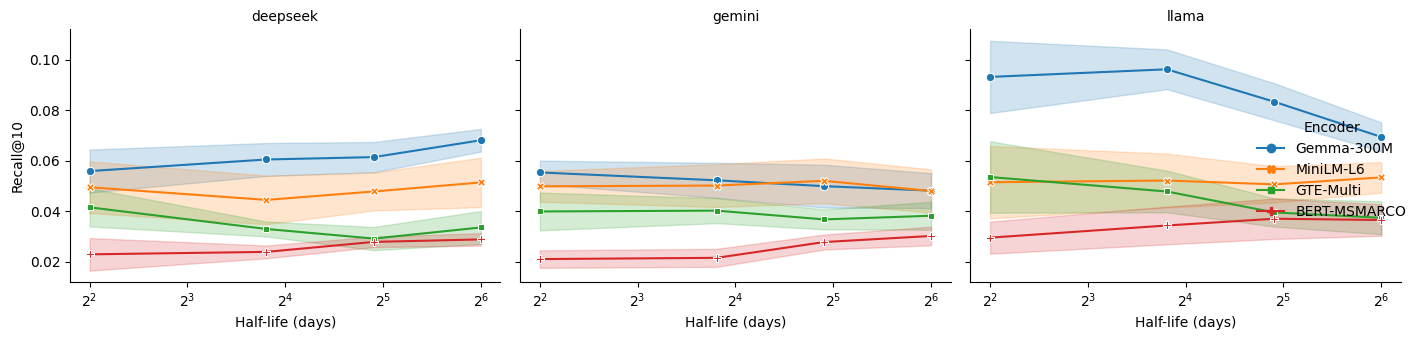

In [6]:
g = sns.relplot(
    data=df,
    x="half_life",
    y="recall@10",
    col="model",
    hue="enc",
    style="enc",
    kind="line",
    height=3.5,
    aspect=1.2,
    palette="tab10",
    markers=True,
    dashes=False,
    errorbar="sd",
    legend="full",
    facet_kws={"sharex": True, "sharey": True}
)
g.set_axis_labels("Half-life (days)", "Recall@10")
g.set_titles("{col_name}")
g._legend.set_title("Encoder")
plt.xscale("log", base=2)  # Since 4, 14, 30, 64 are roughly powers of 2
plt.tight_layout()
plt.savefig("recall_vs_halflife.pdf", bbox_inches='tight')
plt.show()

In [ ]:
g = sns.catplot(
    data=df,
    x="time_window",
    y="recall@10",
    col="model",  # Now model is in columns
    row="enc",
    kind="point",
    height=4,
    aspect=1.0,
    hue="half_life",  # Half-life as color
    palette="bright",
    errorbar="sd",
    legend=True,
    col_wrap=None  # Prevent wrapping
)

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_title("Half Life")
plt.tight_layout()
plt.show()

In [ ]:
g = sns.catplot(
    data=df[df.enc == 'Gemma-300M'],
    x="time_window",
    y="recall@10",
    col="model",  # Now model is in columns
    kind="point",
    height=4,
    aspect=1.0,
    hue="half_life",  # Half-life as color
    palette="bright",
    errorbar="sd",
    legend=True,
    col_wrap=None  # Prevent wrapping
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_title("Half Life")
plt.tight_layout()
plt.show()

In [ ]:
sns.catplot(data = df, y = 'encoder', x = 'recall@10',  palette="Set1",hue = 'encoder', col = 'model', kind = 'box')
plt.show()
sns.catplot(data = df, y = 'encoder', x = 'ndcg@10',  palette="Set1",hue = 'encoder', col = 'model', kind = 'box')
plt.show()

In [ ]:
sns.barplot(data = df[df.enc != 'old'], y = 'model', x = 'recall@10', hue = 'enc')

In [ ]:
df.groupby(['model','encoder'])[['recall@10', 'ndcg@10']].agg(['mean','std'])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import ast

# Load embeddings
data = np.load('output/msmarco-bert-base-dot-v5/seed1/track_embeddings.npz', allow_pickle=True)
embeddings = data['embeddings']
texts = data['texts']
ids = data['ids']

print(f"Loaded {len(embeddings)} embeddings with dimension {embeddings.shape[1]}")

# Parse metadata from text descriptions
def parse_track_info(text):
    """Extract fields from structured text (handles missing fields)"""
    info = {
        'title': None,
        'artist': None,
        'country': None,
        'year': None,
        'main_genre': None,
        'secondary_genre': None
    }
    
    # Extract each field
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        if ':' in line:
            key, value = line.split(':', 1)
            key = key.strip()
            value = value.strip()
            
            if key == 'title':
                info['title'] = value
            elif key == 'artist':
                info['artist'] = value
            elif key == 'origin country':
                info['country'] = value
            elif key == 'album release date':
                info['year'] = value
            elif key == 'main genre':
                info['main_genre'] = value
            elif key == 'secondary genre':
                info['secondary_genre'] = value
    
    return info

# Parse all tracks
track_info = [parse_track_info(text) for text in texts]
df = pd.DataFrame(track_info)
df['track_id'] = ids
df['text'] = texts

# Clean up data - check if fields exist (not None and not empty)
df['has_genre'] = df['main_genre'].notna() & (df['main_genre'] != '') & (df['main_genre'] != 'None')
df['has_artist'] = df['artist'].notna() & (df['artist'] != '') & (df['artist'] != 'None')
df['has_country'] = df['country'].notna() & (df['country'] != '') & (df['country'] != 'None')
df['year_numeric'] = pd.to_numeric(df['year'], errors='coerce')

print(f"\nData completeness:")
print(f"Has title: {df['title'].notna().sum()} ({df['title'].notna().sum()/len(df)*100:.1f}%)")
print(f"Has artist: {df['has_artist'].sum()} ({df['has_artist'].sum()/len(df)*100:.1f}%)")
print(f"Has genre: {df['has_genre'].sum()} ({df['has_genre'].sum()/len(df)*100:.1f}%)")
print(f"Has country: {df['has_country'].sum()} ({df['has_country'].sum()/len(df)*100:.1f}%)")
print(f"Has year: {df['year_numeric'].notna().sum()} ({df['year_numeric'].notna().sum()/len(df)*100:.1f}%)")

# Perform PCA
n_components = min(50, embeddings.shape[1])  # Analyze top 50 components
pca = PCA(n_components=n_components, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

print(f"\nPCA Analysis:")
print(f"Total components: {n_components}")
print(f"Variance explained by first 10 components: {pca.explained_variance_ratio_[:10].sum():.3f}")

# Add PCA components to dataframe
for i in range(min(10, n_components)):  # First 10 components
    df[f'PC{i+1}'] = embeddings_pca[:, i]

# ============================================
# VISUALIZATION 1: Scree Plot (Explained Variance)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, min(21, n_components+1)), 
            pca.explained_variance_ratio_[:20], 
            alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: Variance Explained by Each PC')
axes[0].grid(alpha=0.3)

# Cumulative variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, n_components+1), cumsum, marker='o', markersize=4)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComponents needed for 90% variance: {np.argmax(cumsum >= 0.9) + 1}")
print(f"Components needed for 95% variance: {np.argmax(cumsum >= 0.95) + 1}")

# ============================================
# VISUALIZATION 2: PC1 vs PC2 colored by different attributes
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# By genre (known vs unknown)
axes[0, 0].scatter(df[df['has_genre']]['PC1'], df[df['has_genre']]['PC2'], 
                   c='blue', alpha=0.3, s=20, label='Known genre')
axes[0, 0].scatter(df[~df['has_genre']]['PC1'], df[~df['has_genre']]['PC2'], 
                   c='red', alpha=0.5, s=20, label='Unknown genre')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
axes[0, 0].set_title('PC1 vs PC2: Genre Known/Unknown')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# By specific genres (top genres)
if df['has_genre'].sum() > 0:
    known_genres = df[df['has_genre']]['main_genre'].value_counts()
    top_genres = known_genres.head(8).index.tolist()
    df_top = df[df['main_genre'].isin(top_genres)]

    for genre in top_genres:
        mask = df_top['main_genre'] == genre
        axes[0, 1].scatter(df_top[mask]['PC1'], df_top[mask]['PC2'], 
                           alpha=0.6, s=30, label=genre)
    axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
    axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
    axes[0, 1].set_title('PC1 vs PC2: Top 8 Genres')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0, 1].grid(alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'No genre data available', ha='center', va='center')
    axes[0, 1].set_title('PC1 vs PC2: Top 8 Genres')

# By year (if available)
df_with_year = df[df['year_numeric'].notna()]
if len(df_with_year) > 0:
    scatter = axes[1, 0].scatter(df_with_year['PC1'], df_with_year['PC2'], 
                                 c=df_with_year['year_numeric'], 
                                 cmap='viridis', alpha=0.5, s=20)
    plt.colorbar(scatter, ax=axes[1, 0], label='Year')
    axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
    axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
    axes[1, 0].set_title('PC1 vs PC2: Colored by Year')
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No year data available', ha='center', va='center')
    axes[1, 0].set_title('PC1 vs PC2: Colored by Year')

# By country (top countries)
if df['has_country'].sum() > 0:
    top_countries = df[df['has_country']]['country'].value_counts().head(8).index.tolist()
    df_country = df[df['country'].isin(top_countries)]

    for country in top_countries:
        mask = df_country['country'] == country
        axes[1, 1].scatter(df_country[mask]['PC1'], df_country[mask]['PC2'], 
                           alpha=0.5, s=20, label=country[:20])  # Truncate long names
    axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
    axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
    axes[1, 1].set_title('PC1 vs PC2: Top 8 Countries')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'No country data available', ha='center', va='center')
    axes[1, 1].set_title('PC1 vs PC2: Top 8 Countries')

plt.tight_layout()
plt.savefig('pca_by_attributes.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALIZATION 3: Correlation between PCs and metadata
# ============================================

# Encode categorical variables for correlation
le_genre = LabelEncoder()
le_country = LabelEncoder()

# Initialize with default values
df['genre_encoded'] = 0
df['country_encoded'] = 0

# Encode only where data exists
if df['has_genre'].sum() > 0:
    genre_mask = df['has_genre']
    df.loc[genre_mask, 'genre_encoded'] = le_genre.fit_transform(df.loc[genre_mask, 'main_genre'])

if df['has_country'].sum() > 0:
    country_mask = df['has_country']
    df.loc[country_mask, 'country_encoded'] = le_country.fit_transform(df.loc[country_mask, 'country'])
    
# Create correlation matrix
correlation_data = pd.DataFrame({
    'PC1': df['PC1'],
    'PC2': df['PC2'],
    'PC3': df['PC3'],
    'PC4': df['PC4'],
    'PC5': df['PC5'],
    'Year': df['year_numeric'],
    'Has_Genre': df['has_genre'].astype(int),
    'Genre_ID': df['genre_encoded'],
    'Country_ID': df['country_encoded'],
})

corr_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation between Principal Components and Metadata')
plt.tight_layout()
plt.savefig('pca_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ANALYSIS: Which PC explains what?
# ============================================

print("\n" + "="*60)
print("PRINCIPAL COMPONENT ANALYSIS SUMMARY")
print("="*60)

for i in range(min(5, n_components)):
    print(f"\n--- PC{i+1} (explains {pca.explained_variance_ratio_[i]:.2%} of variance) ---")
    
    # Correlations with metadata
    if df['year_numeric'].notna().sum() > 0:
        year_corr = df[['PC' + str(i+1), 'year_numeric']].dropna().corr().iloc[0, 1]
        print(f"  Correlation with Year: {year_corr:.3f}")
    
    if df['has_genre'].sum() > 10:
        genre_corr = df[df['has_genre']][['PC' + str(i+1), 'genre_encoded']].corr().iloc[0, 1]
        print(f"  Correlation with Genre: {genre_corr:.3f}")
    
    if df['has_country'].sum() > 10:
        country_corr = df[df['has_country']][['PC' + str(i+1), 'country_encoded']].corr().iloc[0, 1]
        print(f"  Correlation with Country: {country_corr:.3f}")
    
    # Distribution stats
    print(f"  Mean: {df['PC' + str(i+1)].mean():.3f}, Std: {df['PC' + str(i+1)].std():.3f}")
    print(f"  Range: [{df['PC' + str(i+1)].min():.3f}, {df['PC' + str(i+1)].max():.3f}]")

# Save processed data
df.to_csv('track_embeddings_pca_analyzed.csv', index=False)
print("\n✓ Saved analyzed data to 'track_embeddings_pca_analyzed.csv'")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Can the embeddings predict genre?
X = embeddings[df['has_genre'].values]
y = df[df['has_genre']]['main_genre'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
print(f"Genre classification accuracy: {clf.score(X_test, y_test):.3f}")

In [ ]:
df.year_num.describe()

In [ ]:
df[df.year_num < 1910][['title','artist','country','year','main_genre']].head(10)

In [ ]:
base_path = '../../../../data/ceph/analysis/eepure/TORS_LLM_biases/'
test = pd.read_csv(base_path +'data/test.csv')

In [ ]:
test.year_release.describe()

In [ ]:
test[test.year_release <= 1905][['song_title','artist_name','year_release','country_name']].drop_duplicates().head()

In [ ]:
test.year_release.quantile(0.01)